In [108]:
import astropy.io.fits as pf
import matplotlib.pyplot as plt
import numpy as np
import sklearn.linear_model as sl
import matplotlib.cm as cm
np.random.seed(42)
def plot_style():

    params = {'legend.fontsize': 20,
             'axes.labelsize': 20,
             'axes.titlesize':20,
             'xtick.labelsize':20,
             'ytick.labelsize':20,
             'xtick.major.size':6,
              'xtick.minor.size':4.5,
             'ytick.major.size':6,
              'ytick.minor.size':3.5,
             'figure.facecolor':'w',
              'xtick.major.width':1.5,
              'ytick.major.width':1.5,
              'xtick.minor.width':1.5,
              'ytick.minor.width':1.5,
              'axes.linewidth':1.5,
              'xtick.direction':'in',
              'ytick.direction':'in',
             'ytick.labelleft':True,
              'text.usetex' : False,
             'font.family': 'sans-serif'}

    plt.rcParams.update(params)
plot_style()

# test https://www.dropbox.com/s/bqu2mchespz8fx8/SDSS_QSO_star_testing.fits?dl=0
# training https://www.dropbox.com/s/js9q7te2nb5sd46/SDSS_QSO_star_training.fits?dl=0

In [109]:
#from google.colab import drive                       # Colab helper to reach Google Drive
#drive.mount('/content/gdrive', force_remount=True)     # mount Drive at /content/gdrive
#root_dir = "/content/gdrive/My Drive/Colab Notebooks/" # folder that holds the .fits files
root_dir = './'
training = pf.open(root_dir+'SDSS_QSO_star_training.fits')

'''
Training[0].data -> matrix[n_object, n_color] n_color==4 u-g, g-r, r-i, i-z
Training[1].data -> 0 stars, 1 QSOs
'''

test = pf.open(root_dir+'SDSS_QSO_star_testing.fits')
# Data example taken from astroML https://www.astroml.org/book_figures/chapter9/fig_star_quasar_ROC.html

(-0.5, 1.5)

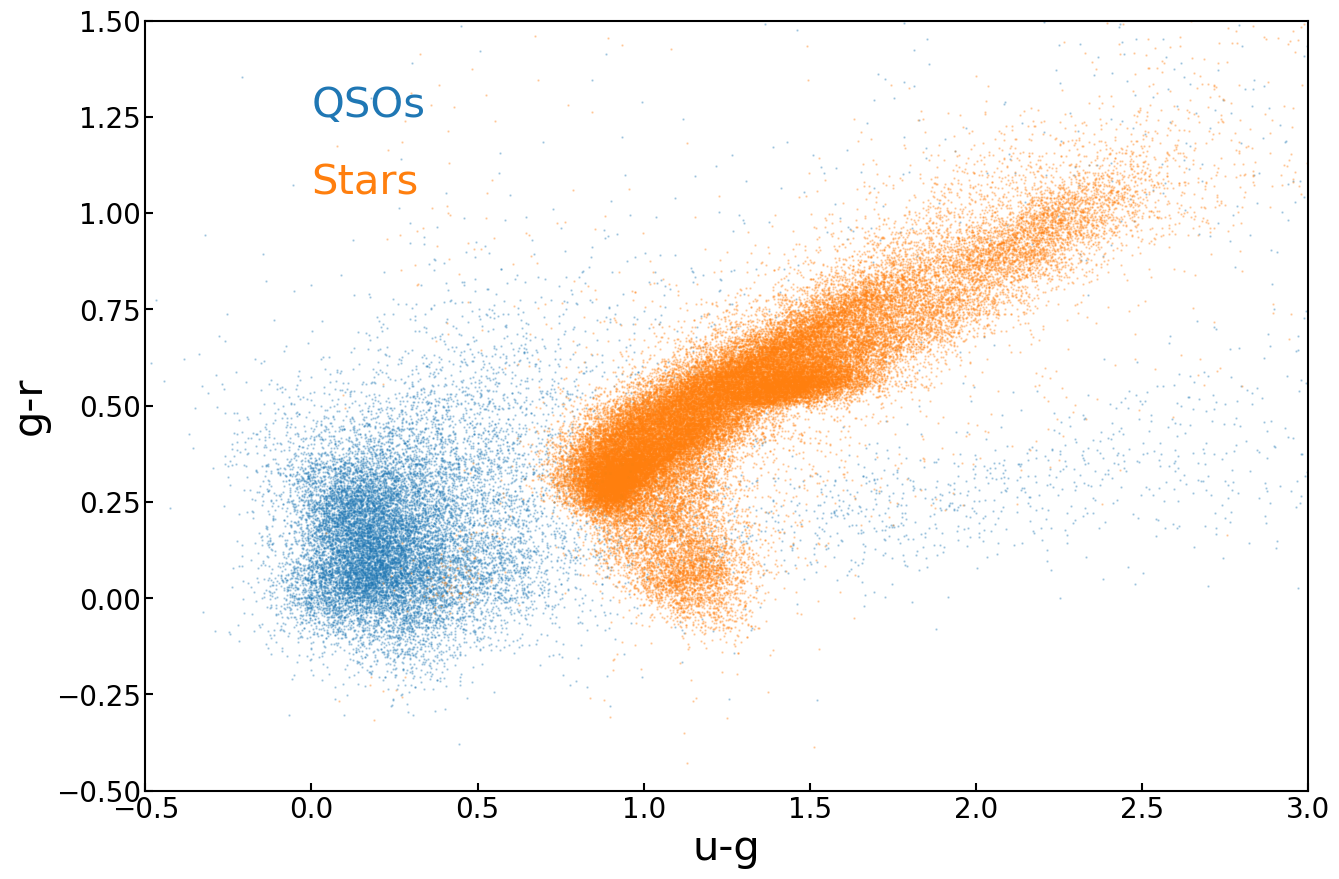

In [110]:
plt.figure(figsize=(15,10))
search = np.where(training[1].data==1)
plt.scatter(training[0].data[search[0],0],training[0].data[search[0],1],c='C0',label='QSO',s=0.5,alpha=0.3)
search = np.where(training[1].data==0)
plt.scatter(training[0].data[search[0],0],training[0].data[search[0],1],c='C1',label='Star',s=0.5,alpha=0.3)
plt.xlabel('u-g',fontsize=30)
plt.ylabel('g-r',fontsize=30)
plt.text(0.,1.25,'QSOs',fontsize=30,color='C0')
plt.text(0.,1.05,'Stars',fontsize=30,color='C1')
plt.xlim(-0.5,3)
plt.ylim(-0.5,1.5)

In [111]:
colors_trainval = training[0].data
labels_trainval = training[1].data

colors_test = test[0].data
labels_test = test[1].data

**Construction training/validation/test datasets**

In [112]:
val_frac = 0.15                                # fraction of the training file held out for validation
                                               # (set this to match the test-set size if you prefer)
M    = len(colors_trainval)                    # size of the train+val pool
perm = np.random.permutation(M)                # shuffle the indices once (seeded above)
n_val = int(val_frac * M)                      # number of validation examples

val_idx   = perm[:n_val]                       # first 15% -> validation
train_idx = perm[n_val:]                       # remaining 85% -> training

In [113]:
color_train = colors_trainval[train_idx]
color_val   = colors_trainval[val_idx]
color_test  = colors_test

label_train = labels_trainval[train_idx]
label_val   = labels_trainval[val_idx]
label_test  = labels_test

**Perform logistic regression**

In [114]:
lg = sl.LogisticRegression() # initial a logistic regression object
lg.fit(color_train,label_train)

alpha = lg.coef_
beta = lg.intercept_

In [115]:
print('alpha',alpha)
print('beta',beta)

alpha [[-3.44498476 -1.87595239  1.79587238  4.57337847]]
beta [1.98596974]


$$t = alpha[0]*(u-g)+alpha[1]*(g-r)+alpha[2]*(r-i)+alpha[3]*(i-z)+beta$$
$$p = \frac{1}{(1.+exp(-1*t)}$$

In [122]:
y_pred = lg.predict(color_train)
y_prob = lg.predict_proba(color_train) # output the predicted probability

In [123]:
def accuracy(true_value, prediction):
    cut = prediction==true_value
    return len(prediction[cut])*1.0/len(prediction)

In [124]:
def completeness_purity(true_value, prediction):
    # true_value / prediction: 1D numpy arrays of 0/1 labels. Convention: class 1 = QSO.
    n_true_qso   = np.sum(true_value == 1)                        # number of real QSOs
    n_qso_as_qso = np.sum((true_value == 1) & (prediction == 1))  # real QSOs correctly found
    n_pred_qso   = np.sum(prediction == 1)                        # objects the model calls QSO

    completeness = n_qso_as_qso / n_true_qso   # fraction of real QSOs recovered  (recall)
    purity       = n_qso_as_qso / n_pred_qso   # fraction of QSO calls that are real (precision)
    return completeness, purity

**Completeness and purity definition**

$$
\rm Completenss \, (recall) = \frac{Number \, of \, true \, quasars \, predicted \, as \, quasars}{Total \, number \, of \, true \, quasars}
$$


$$
\rm Purity \, (precision) = \frac{Number \, of \, true \, quasars \, predicted \, as \, quasars}{Total \, number \, of \, predicted \, quasars}
$$

In [125]:
y_pred = lg.predict(color_train)
y_prob = lg.predict_proba(color_train)
acc = accuracy(label_train, y_pred)
comp, pur = completeness_purity(label_train, y_pred)
print('Training')
print('accuracy %0.4f' % acc)
print(f"completeness = {comp:.4f}   purity = {pur:.4f}   C*P = {comp*pur:.4f}")

y_pred_val = lg.predict(color_val)
acc = accuracy(label_val, y_pred_val)
comp, pur = completeness_purity(label_val, y_pred_val)

print('Validation')
print('accuracy %0.4f' % acc)
print(f"completeness = {comp:.4f}   purity = {pur:.4f}   C*P = {comp*pur:.4f}")

y_pred_test = lg.predict(color_test)
acc = accuracy(label_test, y_pred_test)
comp, pur = completeness_purity(label_test, y_pred_test)

print('Test')
print('accuracy %0.4f' % acc)
print(f"completeness = {comp:.4f}   purity = {pur:.4f}   C*P = {comp*pur:.4f}")


Training
accuracy 0.9620
completeness = 0.8491   purity = 0.9943   C*P = 0.8443
Validation
accuracy 0.9621
completeness = 0.8462   purity = 0.9954   C*P = 0.8423
Test
accuracy 0.9607
completeness = 0.8468   purity = 0.9951   C*P = 0.8426


(-0.5, 1.5)

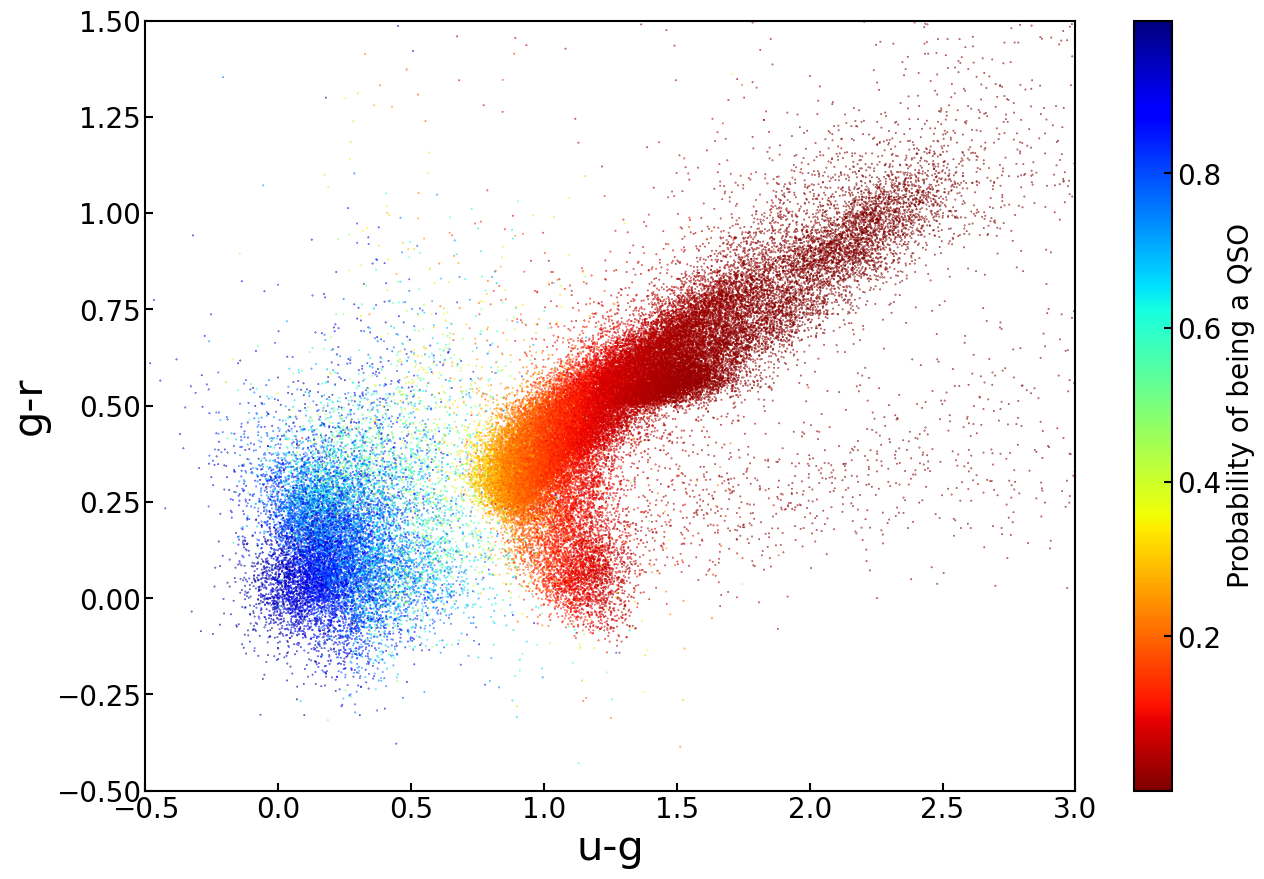

In [126]:
plt.figure(figsize=(15,10))
plt.scatter(color_train[:,0],color_train[:,1],c=y_prob[:,1],s=0.1,cmap=cm.jet_r)
plt.colorbar(label='Probability of being a QSO')
plt.xlabel('u-g',fontsize=30)
plt.ylabel('g-r',fontsize=30)
plt.xlim(-0.5,3)
plt.ylim(-0.5,1.5)